# INT221 - Basketball Team Performance Analysis
### Manu Bansal

**Objective:** Big East college basketball teams and analysts use historical team and game statistics to evaluate performance and understand what drives winning seasons. Identify the key performance drivers to estimate win percentage, rankings, or season success and support data-driven coaching and recruitment decisions.

**This notebook covers:**
1. Data Loading & Understanding
2. Data Wrangling (Null handling, Duplicates, Outliers)
3. Feature Engineering
4. Encoding Categorical Variables
5. Exploratory Data Analysis (EDA)
6. Hypothesis Framing & Testing
7. Classification Model & Confusion Matrix
8. Final Observations

---
## 1. Installing & Importing Libraries

In [1]:
pip install matplotlib pandas numpy seaborn scikit-learn scipy

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 11.8 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.1 MB 11.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.9 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/37.3 MB 11.9 MB/s eta 0:00:03
   ---- ----------------------------------- 4.5/37.3 MB 11.3 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/37.3 MB 11.5 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/37.3 MB 11.6 MB/s eta 0:00:03
   ------------ --------------------------- 12.1/37.3 MB 11.5 MB/s eta 0:00:03
   --------------- ------------------------ 14.4/37.3 MB 11.5 MB/s eta 0:00:02
   ------------------ --------------------- 17.0/37.3 MB 11.5 MB/s eta 0:00:02
   ----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, ttest_rel, chi2_contingency, spearmanr
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 2. Loading the Dataset

In [3]:
df = pd.read_csv("11_Baseketball_Team_Performance_Analysis.csv")
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset Shape: (10000, 37)
Rows: 10000, Columns: 37


,id,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
0,1,2021,1,Villanova,38,30,8,0.789,16,4,...,10.3,34.8,11.9,6.0,2.2,9.9,14.9,71.7,62.7,19.31
1,2,2021,2,Providence,33,27,6,0.818,14,3,...,10.5,37.6,13.2,5.0,3.7,11.4,16.0,71.5,66.2,13.08
2,3,2021,3,UConn,33,23,10,0.697,13,6,...,13.8,40.4,14.0,5.9,6.4,11.8,16.8,74.8,65.3,16.40
3,4,2021,4,Creighton,35,23,12,0.657,12,7,...,9.6,38.1,13.3,5.5,4.3,14.1,13.6,69.2,66.4,11.34
4,5,2021,5,Marquette,32,19,13,0.594,11,8,...,7.8,34.8,16.0,7.8,5.2,12.4,17.4,74.0,71.6,11.36


### 2.1 Understanding the Dataset Structure
Let's check data types, non-null counts, and basic statistics.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               10000 non-null  int64  
 1   year                             10000 non-null  int64  
 2   rank                             10000 non-null  int64  
 3   school                           10000 non-null  str    
 4   games                            10000 non-null  int64  
 5   wins                             10000 non-null  int64  
 6   losses                           10000 non-null  int64  
 7   win_percentage                   10000 non-null  float64
 8   conference_wins                  10000 non-null  int64  
 9   conference_losses                10000 non-null  int64  
 10  home_wins                        9792 non-null   float64
 11  home_losses                      9792 non-null   float64
 12  away_wins                     

In [5]:
# Column names and data types overview
print("Column Names:")
print(df.columns.tolist())
print(f"\nUnique Schools: {df['school'].nunique()}")
print(f"Year Range: {df['year'].min()} - {df['year'].max()}")

Column Names:
['id', 'year', 'rank', 'school', 'games', 'wins', 'losses', 'win_percentage', 'conference_wins', 'conference_losses', 'home_wins', 'home_losses', 'away_wins', 'away_losses', 'offensive_rating', 'defensive_rating', 'net_rating', 'field_goals', 'field_goal_attempts', 'field_goal_percentage', '3_pointers', '3_pointer_attempts', '3_pointer_percentage', 'effective_field_goal_percentage', 'free_throws', 'free_throw_attempts', 'free_throw_percentage', 'offensive_rebounds', 'total_rebounds', 'assists', 'steals', 'blocks', 'turnovers', 'personal_fouls', 'points', 'opponent_points', 'simple_rating']

Unique Schools: 22
Year Range: 1979 - 2021


---
## 3. Data Wrangling

### 3.1 Checking & Handling NULL Values

In [6]:
# Count null values per column
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print("Columns with NULL values:")
null_df[null_df['Null Count'] > 0]

Columns with NULL values:


,Null Count,Null %
home_wins,208,2.08
home_losses,208,2.08
away_wins,208,2.08
away_losses,208,2.08
offensive_rating,278,2.78
defensive_rating,278,2.78
net_rating,278,2.78
3_pointers,58,0.58
3_pointer_attempts,58,0.58
3_pointer_percentage,58,0.58


**Observation:** Several columns have missing values (home_wins, away_wins, offensive_rating, 3_pointers, etc.).

**Strategy:** Fill numeric nulls with **column mean** since these are continuous stats with roughly symmetric distributions. Mean imputation preserves the overall distribution shape.

In [7]:
# Fill null values with column mean for numeric columns
df = df.fillna(df.mean(numeric_only=True))

# Verify no nulls remain
print("Null values after handling:")
print(df.isnull().sum().sum(), "total nulls remaining")

Null values after handling:
0 total nulls remaining


### 3.2 Checking & Removing Duplicates

In [8]:
print(f"Duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (10000, 37)


### 3.3 Dropping the `id` Column
The `id` column is just a row identifier with no analytical value. Keeping it would pollute correlations.

In [9]:
df = df.drop(columns=['id'])
print(f"Shape after dropping 'id': {df.shape}")
df.head()

Shape after dropping 'id': (10000, 36)


,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,home_wins,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
0,2021,1,Villanova,38,30,8,0.789,16,4,12.0,...,10.3,34.8,11.9,6.0,2.2,9.9,14.9,71.7,62.7,19.31
1,2021,2,Providence,33,27,6,0.818,14,3,16.0,...,10.5,37.6,13.2,5.0,3.7,11.4,16.0,71.5,66.2,13.08
2,2021,3,UConn,33,23,10,0.697,13,6,14.0,...,13.8,40.4,14.0,5.9,6.4,11.8,16.8,74.8,65.3,16.40
3,2021,4,Creighton,35,23,12,0.657,12,7,11.0,...,9.6,38.1,13.3,5.5,4.3,14.1,13.6,69.2,66.4,11.34
4,2021,5,Marquette,32,19,13,0.594,11,8,13.0,...,7.8,34.8,16.0,7.8,5.2,12.4,17.4,74.0,71.6,11.36


### 3.4 Descriptive Statistics

In [10]:
df.describe()

,year,rank,games,wins,losses,win_percentage,conference_wins,conference_losses,home_wins,home_losses,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2000.018200,8.37160,31.367000,20.434800,13.602200,0.600213,8.545300,9.935300,11.064645,5.461806,...,12.322711,36.379410,14.799860,8.009976,4.842250,14.270301,19.048081,72.791880,68.621000,11.144945
std,12.403034,4.63839,6.107474,9.063916,6.801175,0.187888,5.143986,5.387246,4.904815,3.399607,...,2.691445,4.126262,2.899868,2.151376,2.029471,2.866609,3.156736,6.641915,6.022472,5.893731
min,1979.000000,1.00000,19.000000,5.000000,2.000000,0.194000,0.000000,1.000000,2.000000,0.000000,...,7.500000,27.700000,8.800000,4.000000,1.400000,8.700000,12.700000,58.800000,53.500000,0.000000
25%,1989.000000,4.00000,27.000000,13.000000,8.000000,0.464000,4.000000,5.000000,7.000000,3.000000,...,10.100000,33.100000,12.500000,6.200000,3.200000,11.800000,16.500000,67.900000,64.300000,6.910000
50%,2000.000000,8.00000,32.000000,20.000000,14.000000,0.618000,9.000000,10.000000,11.000000,5.461806,...,12.300000,36.300000,14.700000,8.000000,4.700000,14.200000,18.900000,72.700000,68.500000,11.350000
75%,2011.000000,12.00000,36.000000,28.000000,19.000000,0.750000,13.000000,15.000000,15.000000,8.000000,...,14.300000,39.500000,17.000000,9.700000,6.300000,16.500000,21.400000,77.900000,73.200000,15.480000
max,2021.000000,16.00000,41.000000,36.000000,25.000000,0.944000,17.000000,19.000000,19.000000,11.000000,...,18.600000,45.500000,20.800000,13.100000,9.100000,20.900000,28.400000,89.700000,83.000000,26.640000


---
## 4. Outlier Detection & Handling

### 4.1 Visualizing Outliers using Boxplots

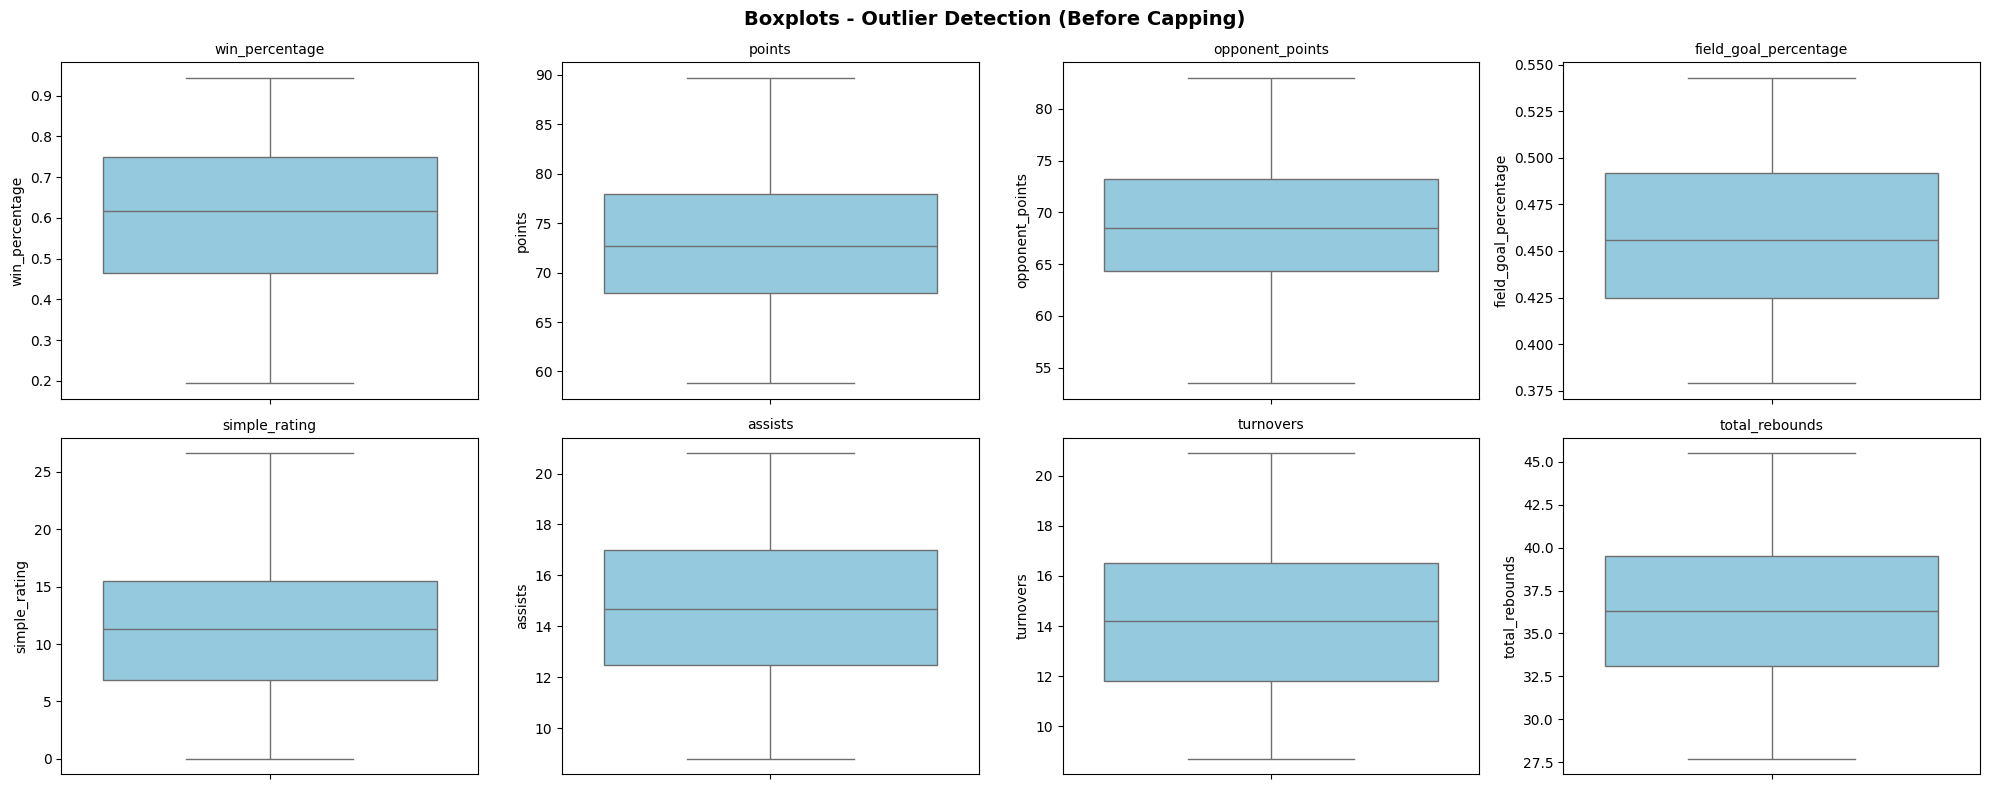

In [11]:
# Boxplots for key performance columns
cols_to_check = ['win_percentage', 'points', 'opponent_points', 'field_goal_percentage',
                 'simple_rating', 'assists', 'turnovers', 'total_rebounds']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Boxplots - Outlier Detection (Before Capping)', fontsize=14, fontweight='bold')

for i, col in enumerate(cols_to_check):
    row, col_idx = i // 4, i % 4
    sns.boxplot(y=df[col], ax=axes[row][col_idx], color='skyblue')
    axes[row][col_idx].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

### 4.2 Counting Outliers using IQR Method

In [12]:
# Count outliers per column using IQR
def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[column] < lower) | (df[column] > upper)).sum()

numeric_cols = df.select_dtypes(include='number').columns
outlier_counts = {col: count_outliers(df, col) for col in numeric_cols}
outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
outlier_df = outlier_df[outlier_df['Outlier Count'] > 0].sort_values('Outlier Count', ascending=False)
print("Columns with outliers (IQR method):")
outlier_df

Columns with outliers (IQR method):


,Outlier Count
offensive_rating,68
3_pointer_attempts,62


### 4.3 Capping Outliers (Winsorization)
**Why capping instead of removing?** In sports data, extreme values are often genuine (e.g., a dominant team). Capping reduces their impact without losing data rows.

In [13]:
# Cap outliers using IQR bounds
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    df[column] = df[column].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    return df

for col in numeric_cols:
    df = cap_outliers(df, col)

print("Outliers capped successfully!")
print(f"Dataset shape remains: {df.shape}")

Outliers capped successfully!
Dataset shape remains: (10000, 36)


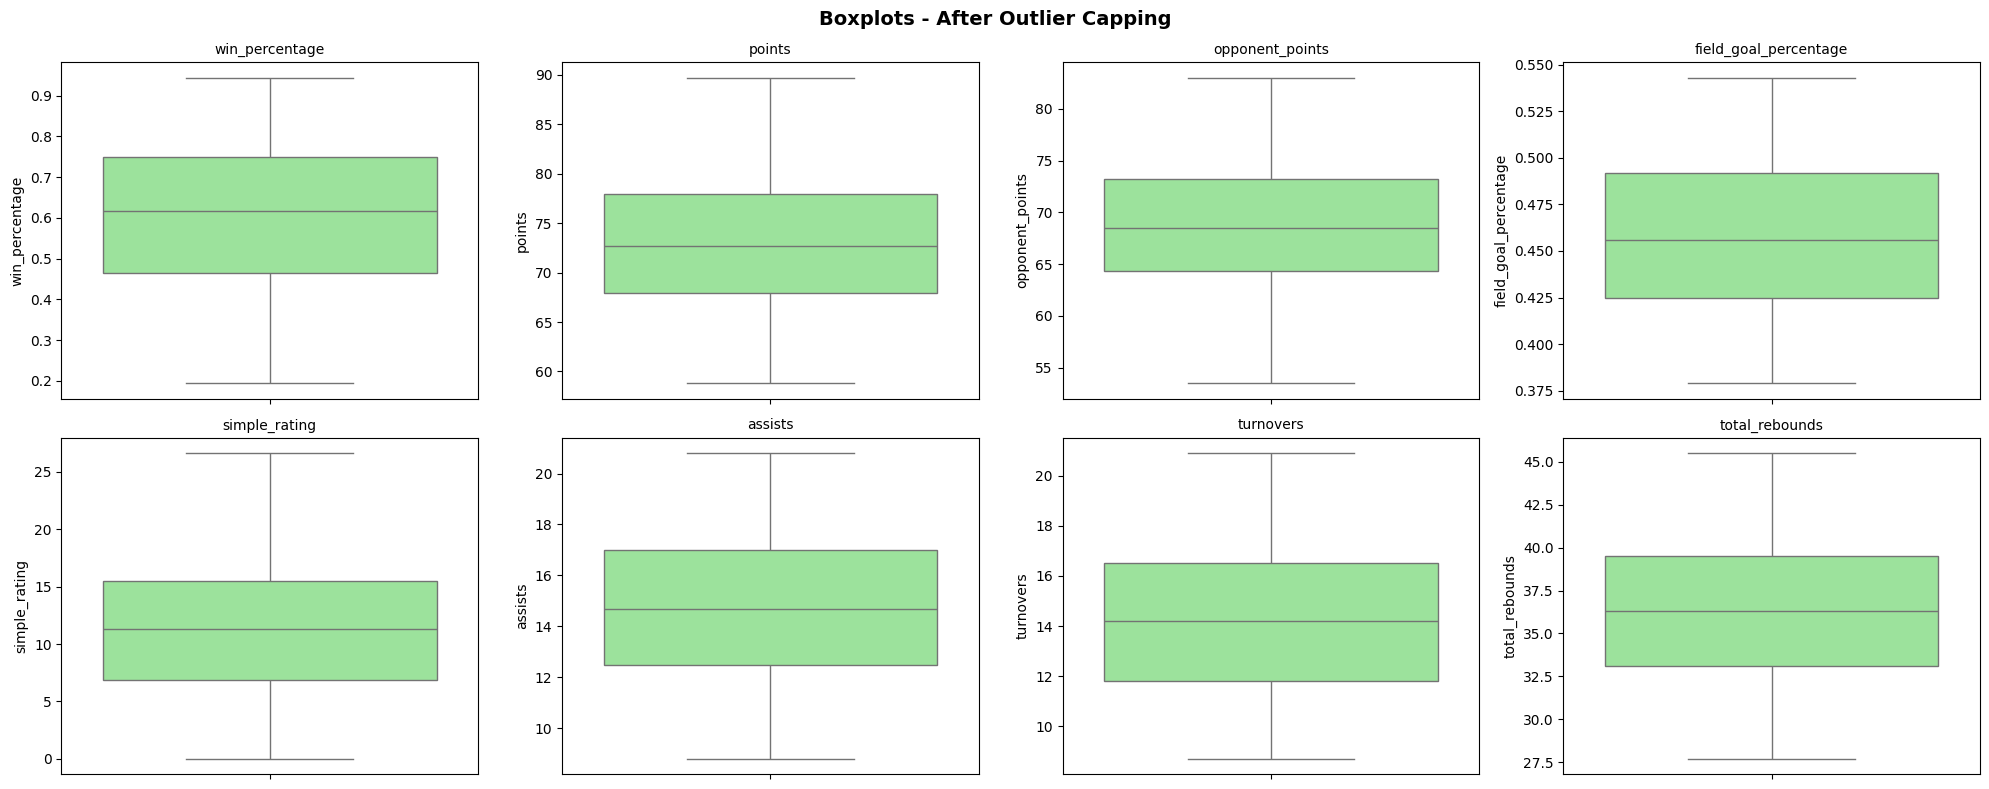

In [14]:
# Boxplots AFTER capping to verify
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Boxplots - After Outlier Capping', fontsize=14, fontweight='bold')

cols_to_check = ['win_percentage', 'points', 'opponent_points', 'field_goal_percentage',
                 'simple_rating', 'assists', 'turnovers', 'total_rebounds']

for i, col in enumerate(cols_to_check):
    row, col_idx = i // 4, i % 4
    sns.boxplot(y=df[col], ax=axes[row][col_idx], color='lightgreen')
    axes[row][col_idx].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Feature Engineering
Creating new meaningful features that capture performance insights beyond raw stats.

In [15]:
# Point Differential - core measure of team dominance
df['point_diff'] = df['points'] - df['opponent_points']

# Home Win Percentage - measures home court advantage
df['home_win_pct'] = df['home_wins'] / (df['home_wins'] + df['home_losses'])

# Away Win Percentage - measures road performance
df['away_win_pct'] = df['away_wins'] / (df['away_wins'] + df['away_losses'])

# Conference Win Percentage - conference strength indicator
df['conference_win_pct'] = df['conference_wins'] / (df['conference_wins'] + df['conference_losses'])

# Assist-to-Turnover Ratio - ball handling efficiency
df['assist_turnover_ratio'] = df['assists'] / df['turnovers']

# Win Category - binary label for classification (above/below median win%)
median_win_pct = df['win_percentage'].median()
df['win_category'] = df['win_percentage'].apply(lambda x: 'High' if x >= median_win_pct else 'Low')

print("New features created:")
print(['point_diff', 'home_win_pct', 'away_win_pct', 'conference_win_pct', 'assist_turnover_ratio', 'win_category'])
df[['school', 'win_percentage', 'point_diff', 'home_win_pct', 'away_win_pct', 
    'conference_win_pct', 'assist_turnover_ratio', 'win_category']].head(10)

New features created:
['point_diff', 'home_win_pct', 'away_win_pct', 'conference_win_pct', 'assist_turnover_ratio', 'win_category']


,school,win_percentage,point_diff,home_win_pct,away_win_pct,conference_win_pct,assist_turnover_ratio,win_category
0,Villanova,0.789,9.0,0.923077,0.615385,0.800000,1.202020,High
1,Providence,0.818,5.3,0.941176,0.777778,0.823529,1.157895,High
2,UConn,0.697,9.5,0.875000,0.500000,0.684211,1.186441,High
3,Creighton,0.657,2.8,0.733333,0.545455,0.631579,0.943262,High
4,Marquette,0.594,2.4,0.812500,0.363636,0.578947,1.290323,Low
5,Seton Hall,0.656,5.5,0.812500,0.545455,0.578947,0.851240,High
6,St. John's (NY),0.531,5.4,0.631579,0.363636,0.421053,1.579832,Low
7,Xavier,0.639,4.9,0.761905,0.400000,0.421053,1.264957,High
8,Butler,0.424,-3.1,0.562500,0.272727,0.300000,0.916667,Low
9,DePaul,0.484,1.1,0.611111,0.333333,0.300000,0.926829,Low


---
## 6. Encoding Categorical Variables

### 6.1 Label Encoding for `school`
Label Encoding assigns a unique number to each school. We keep the original column for reference.

In [16]:
le = LabelEncoder()
df['school_encoded'] = le.fit_transform(df['school'])

print("Label Encoding Mapping:")
encoding_map = df[['school', 'school_encoded']].drop_duplicates().sort_values('school_encoded')
encoding_map

Label Encoding Mapping:


,school,school_encoded
219,Boston College,0
8,Butler,1
100,Cincinnati,2
3,Creighton,3
9,DePaul,4
10,Georgetown,5
93,Louisville,6
4,Marquette,7
243,Miami (FL),8
96,Notre Dame,9


### 6.2 One-Hot Encoding for `win_category`
One-Hot encoding creates binary columns — useful for classification.

In [17]:
# One-Hot Encode win_category
df_encoded = pd.get_dummies(df, columns=['win_category'], prefix='win_cat', drop_first=False)
print("One-Hot Encoded columns added:")
print([c for c in df_encoded.columns if 'win_cat' in c])
df_encoded[[c for c in df_encoded.columns if 'win_cat' in c]].head()

One-Hot Encoded columns added:
['win_cat_High', 'win_cat_Low']


,win_cat_High,win_cat_Low
0,True,False
1,True,False
2,True,False
3,True,False
4,False,True


---
## 7. Exploratory Data Analysis (EDA)

### 7.1 Distribution of Win Percentage

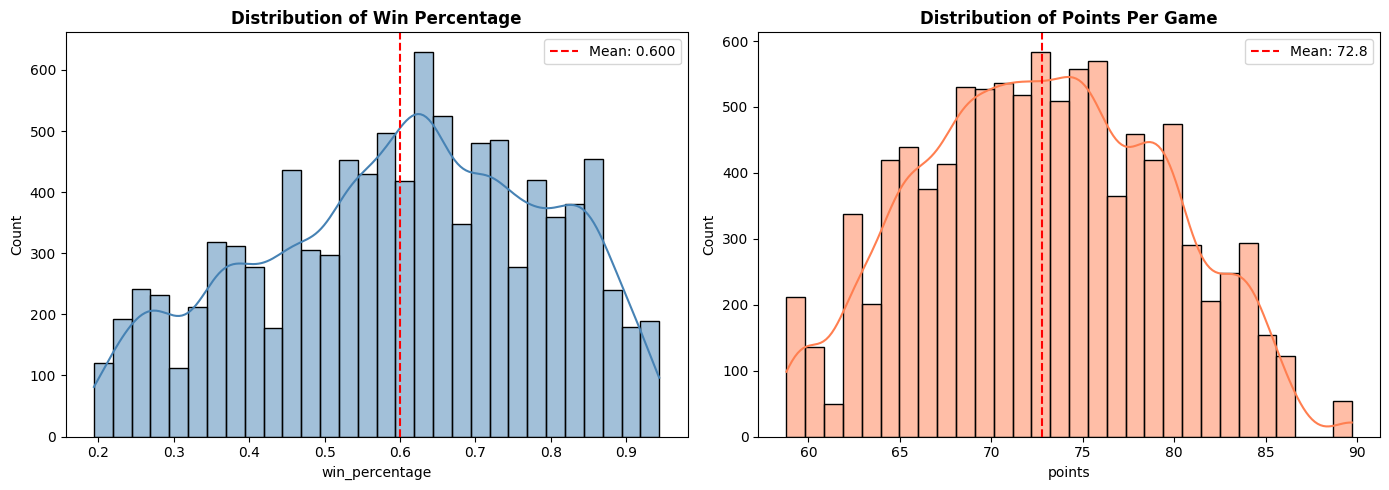

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df['win_percentage'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Win Percentage', fontweight='bold')
axes[0].axvline(df['win_percentage'].mean(), color='red', linestyle='--', label=f"Mean: {df['win_percentage'].mean():.3f}")
axes[0].legend()

# Points distribution
sns.histplot(df['points'], bins=30, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Distribution of Points Per Game', fontweight='bold')
axes[1].axvline(df['points'].mean(), color='red', linestyle='--', label=f"Mean: {df['points'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.2 Correlation Heatmap
Identifying which stats are most strongly correlated with win percentage.

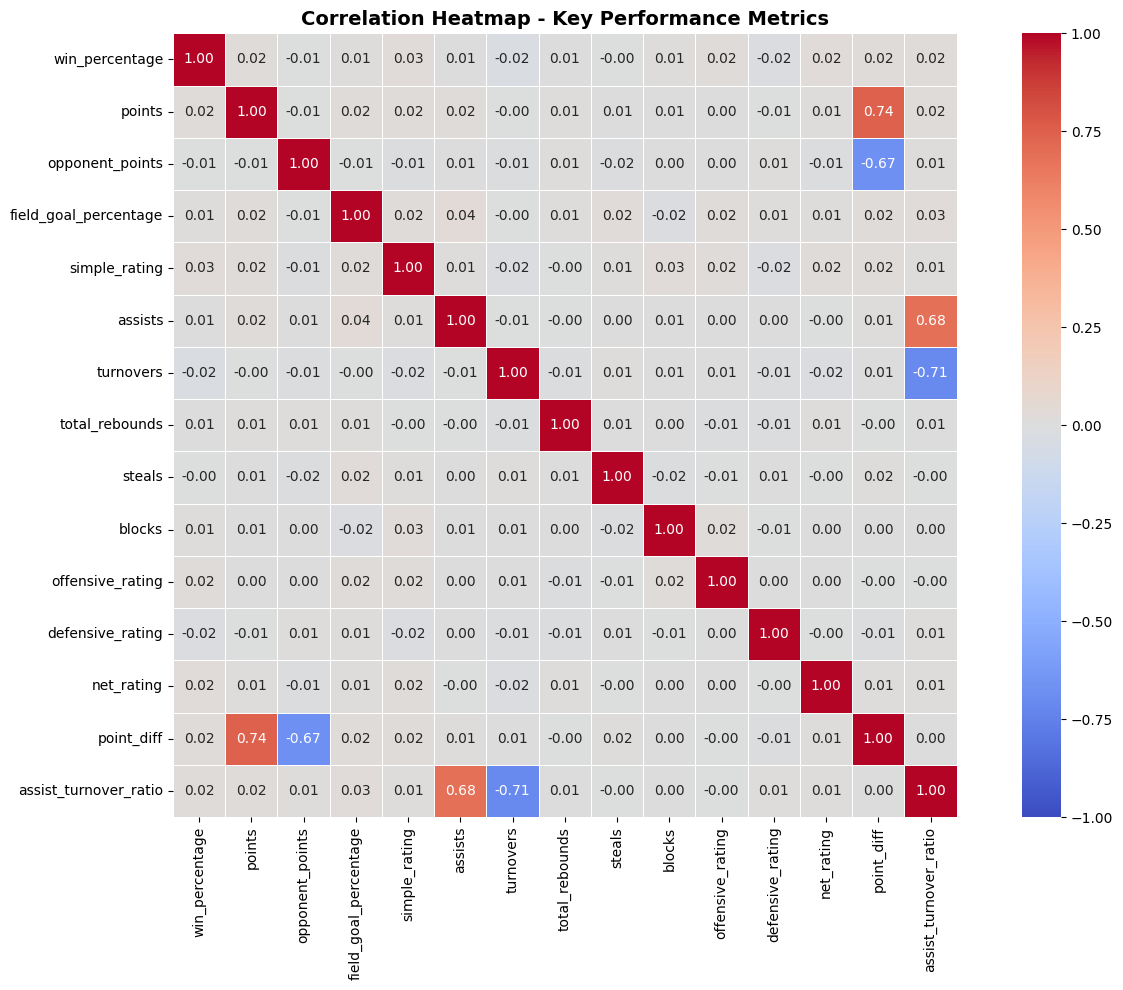

In [19]:
# Select key columns for heatmap
key_cols = ['win_percentage', 'points', 'opponent_points', 'field_goal_percentage',
            'simple_rating', 'assists', 'turnovers', 'total_rebounds', 'steals',
            'blocks', 'offensive_rating', 'defensive_rating', 'net_rating',
            'point_diff', 'assist_turnover_ratio']

corr_matrix = df[key_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Key Performance Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Observations from Heatmap:**
- `simple_rating`, `net_rating`, and `point_diff` are strongly correlated with `win_percentage`
- `field_goal_percentage` has a positive correlation with winning
- `turnovers` tends to have a negative impact on performance

### 7.3 Pairplot - Key Variables

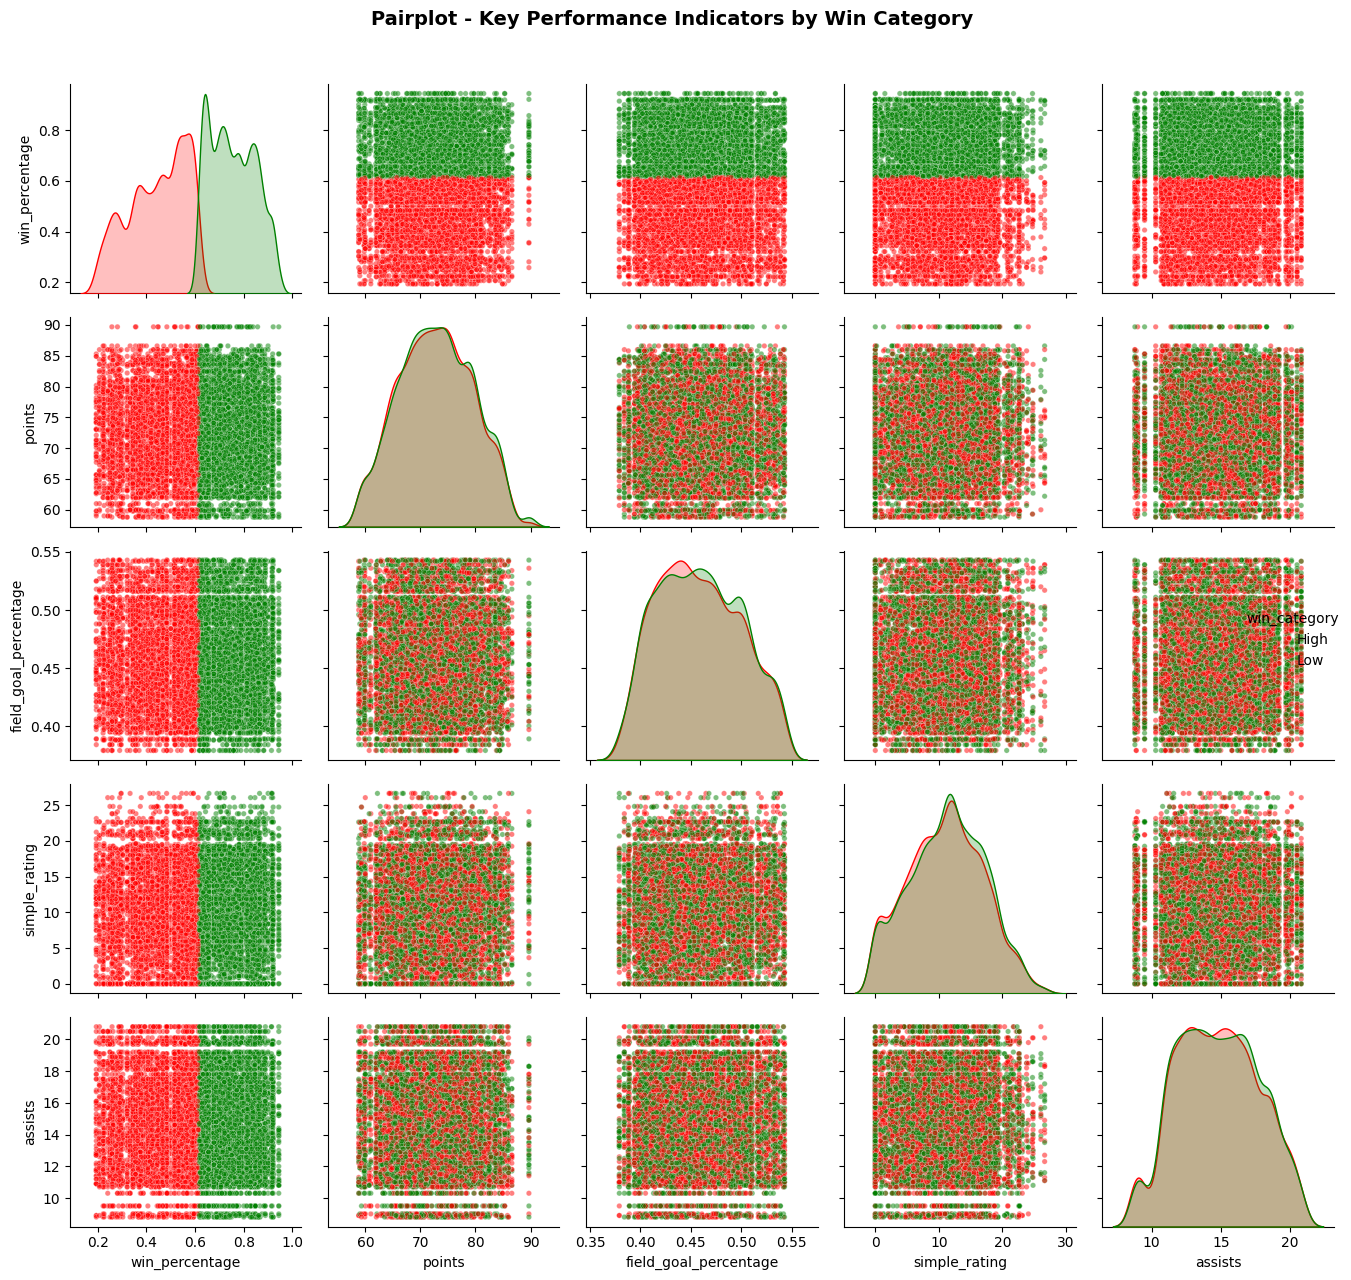

In [20]:
# Pairplot for key performance indicators
pair_cols = ['win_percentage', 'points', 'field_goal_percentage', 'simple_rating', 'assists']
sns.pairplot(df[pair_cols + ['win_category']], hue='win_category', 
             palette={'High': 'green', 'Low': 'red'}, diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pairplot - Key Performance Indicators by Win Category', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Average Win Percentage by School

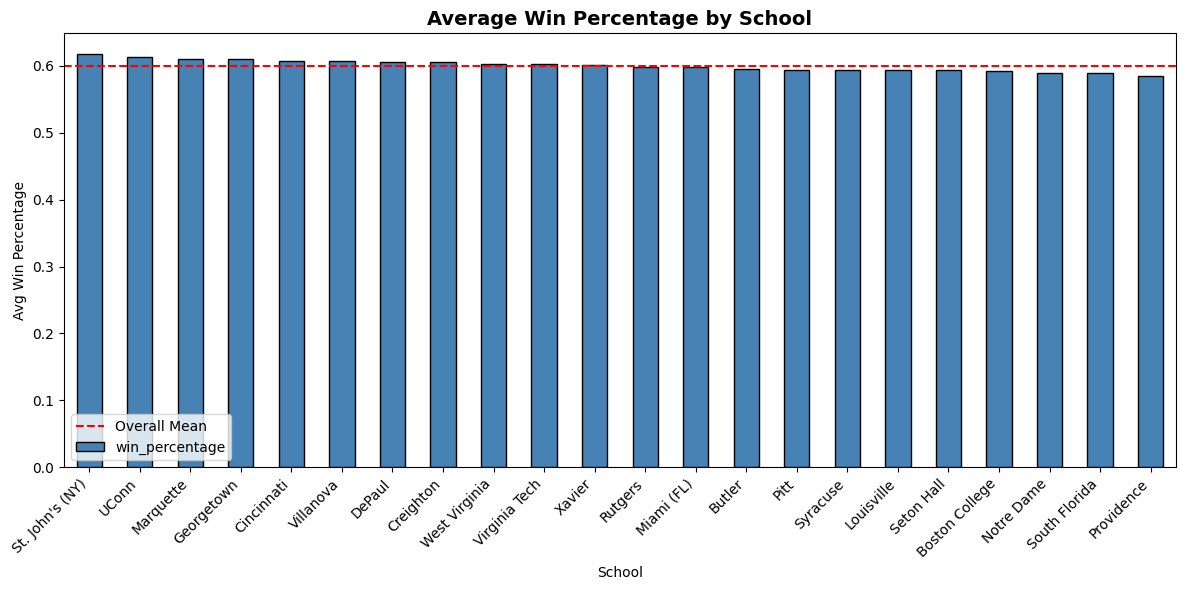

In [21]:
school_avg = df.groupby('school')['win_percentage'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
school_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Win Percentage by School', fontsize=14, fontweight='bold')
plt.xlabel('School')
plt.ylabel('Avg Win Percentage')
plt.axhline(y=df['win_percentage'].mean(), color='red', linestyle='--', label='Overall Mean')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.5 Points vs Win Percentage (Scatter Plot)

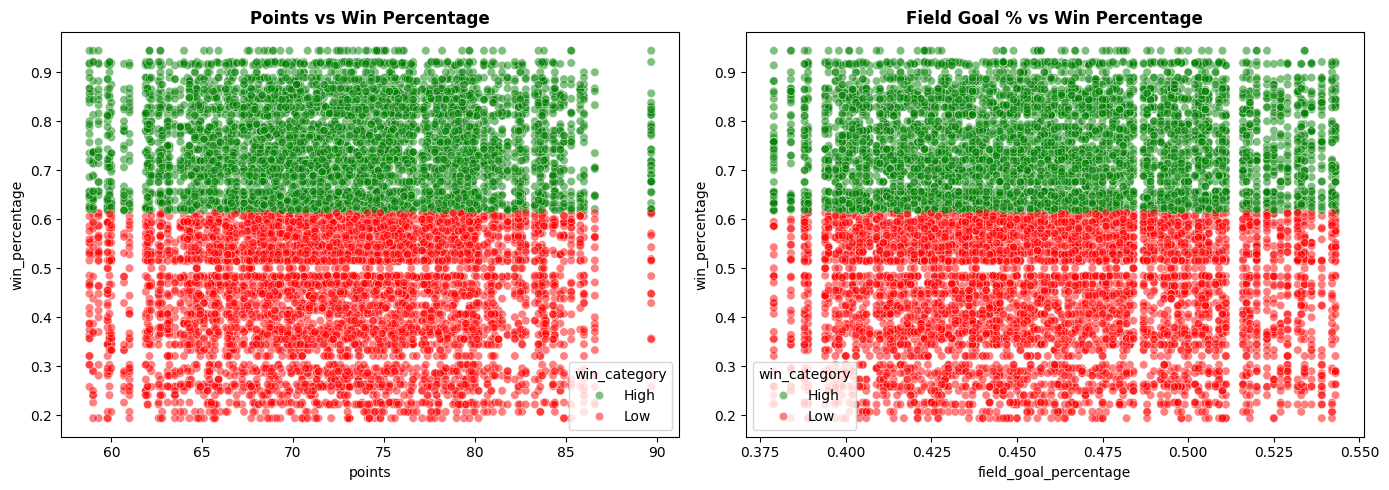

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Points vs Win%
sns.scatterplot(data=df, x='points', y='win_percentage', hue='win_category',
                palette={'High': 'green', 'Low': 'red'}, alpha=0.5, ax=axes[0])
axes[0].set_title('Points vs Win Percentage', fontweight='bold')

# FG% vs Win%
sns.scatterplot(data=df, x='field_goal_percentage', y='win_percentage', hue='win_category',
                palette={'High': 'green', 'Low': 'red'}, alpha=0.5, ax=axes[1])
axes[1].set_title('Field Goal % vs Win Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.6 Top vs Bottom Teams Comparison

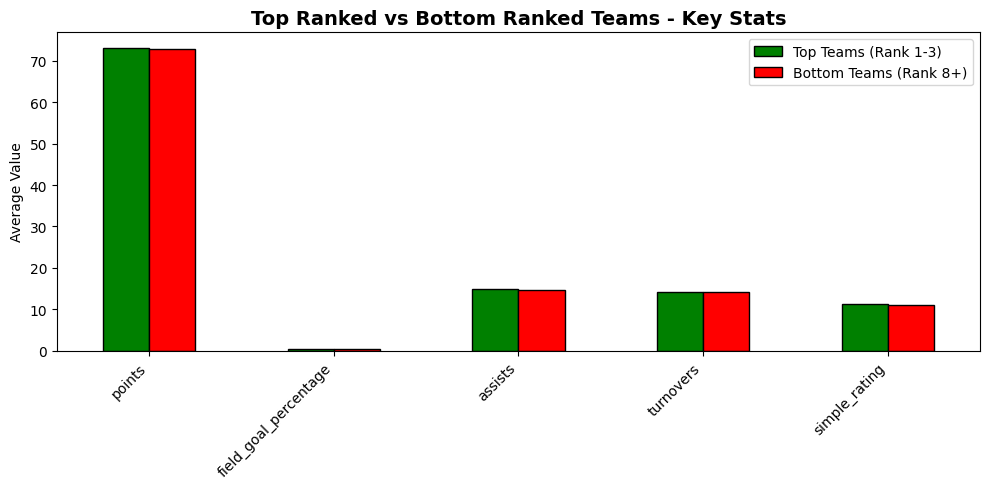

,Top Teams (Rank 1-3),Bottom Teams (Rank 8+)
points,73.15,72.68
field_goal_percentage,0.46,0.46
assists,14.88,14.77
turnovers,14.31,14.28
simple_rating,11.28,11.01


In [23]:
# Compare rank 1-3 vs bottom ranked teams
top_teams = df[df['rank'] <= 3]
bottom_teams = df[df['rank'] >= 8]

compare_cols = ['points', 'field_goal_percentage', 'assists', 'turnovers', 'simple_rating']
comparison = pd.DataFrame({
    'Top Teams (Rank 1-3)': top_teams[compare_cols].mean(),
    'Bottom Teams (Rank 8+)': bottom_teams[compare_cols].mean()
}).round(2)

comparison.plot(kind='bar', figsize=(10, 5), color=['green', 'red'], edgecolor='black')
plt.title('Top Ranked vs Bottom Ranked Teams - Key Stats', fontsize=14, fontweight='bold')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

comparison

---
## 8. Hypothesis Framing & Testing

We frame 5 hypotheses relevant to identifying key performance drivers for basketball team success.

**Significance Level: α = 0.05**

| # | Hypothesis | Test Method |
|---|-----------|-------------|
| H1 | Higher field goal percentage leads to higher win percentage | Pearson Correlation |
| H2 | Teams with positive net rating win significantly more than teams with negative net rating | Independent t-test |
| H3 | Assist-to-turnover ratio is significantly correlated with win percentage | Pearson Correlation |
| H4 | Home win percentage is significantly higher than away win percentage | Paired t-test |
| H5 | There is a significant difference in points scored between high-win and low-win teams | Independent t-test |

### Hypothesis 1: Higher Field Goal % → Higher Win %
- **H₀ (Null):** There is no significant correlation between field goal percentage and win percentage.
- **H₁ (Alternative):** There is a significant positive correlation between field goal percentage and win percentage.
- **Test:** Pearson Correlation

In [24]:
corr, p_value = pearsonr(df['field_goal_percentage'], df['win_percentage'])

print("=" * 60)
print("HYPOTHESIS 1: Field Goal % vs Win Percentage")
print("=" * 60)
print(f"Pearson Correlation Coefficient: {corr:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Significance Level (α): 0.05")
print("-" * 60)
if p_value < 0.05:
    print("✅ RESULT: Reject H₀ — There IS a significant positive correlation.")
    print(f"   Teams with higher field goal % tend to have higher win %.")
else:
    print("❌ RESULT: Fail to reject H₀ — No significant correlation found.")
print("=" * 60)

HYPOTHESIS 1: Field Goal % vs Win Percentage
Pearson Correlation Coefficient: 0.0143
P-value: 1.52e-01
Significance Level (α): 0.05
------------------------------------------------------------
❌ RESULT: Fail to reject H₀ — No significant correlation found.


### Hypothesis 2: Positive Net Rating → More Wins
- **H₀ (Null):** There is no significant difference in win percentage between teams with positive and negative net ratings.
- **H₁ (Alternative):** Teams with positive net rating have significantly higher win percentage.
- **Test:** Independent Samples t-test

In [25]:
positive_net = df[df['net_rating'] > 0]['win_percentage']
negative_net = df[df['net_rating'] <= 0]['win_percentage']

t_stat, p_value = ttest_ind(positive_net, negative_net)

print("=" * 60)
print("HYPOTHESIS 2: Net Rating vs Win Percentage")
print("=" * 60)
print(f"Positive Net Rating - Mean Win%: {positive_net.mean():.4f} (n={len(positive_net)})")
print(f"Negative Net Rating - Mean Win%: {negative_net.mean():.4f} (n={len(negative_net)})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Significance Level (α): 0.05")
print("-" * 60)
if p_value < 0.05:
    print("✅ RESULT: Reject H₀ — Teams with positive net rating win significantly more.")
else:
    print("❌ RESULT: Fail to reject H₀ — No significant difference found.")
print("=" * 60)

HYPOTHESIS 2: Net Rating vs Win Percentage
Positive Net Rating - Mean Win%: 0.6022 (n=7584)
Negative Net Rating - Mean Win%: 0.5941 (n=2416)
T-statistic: 1.8325
P-value: 6.69e-02
Significance Level (α): 0.05
------------------------------------------------------------
❌ RESULT: Fail to reject H₀ — No significant difference found.


### Hypothesis 3: Assist-to-Turnover Ratio Correlates with Win %
- **H₀ (Null):** There is no significant correlation between assist-to-turnover ratio and win percentage.
- **H₁ (Alternative):** There is a significant correlation between assist-to-turnover ratio and win percentage.
- **Test:** Pearson Correlation

In [26]:
# Drop any inf values from the ratio
valid_data = df[np.isfinite(df['assist_turnover_ratio'])]

corr, p_value = pearsonr(valid_data['assist_turnover_ratio'], valid_data['win_percentage'])

print("=" * 60)
print("HYPOTHESIS 3: Assist-to-Turnover Ratio vs Win Percentage")
print("=" * 60)
print(f"Pearson Correlation Coefficient: {corr:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Significance Level (α): 0.05")
print("-" * 60)
if p_value < 0.05:
    print("✅ RESULT: Reject H₀ — Assist-to-turnover ratio IS significantly correlated with win %.")
    print(f"   Better ball handling (higher A/T ratio) is linked to more wins.")
else:
    print("❌ RESULT: Fail to reject H₀ — No significant correlation found.")
print("=" * 60)

HYPOTHESIS 3: Assist-to-Turnover Ratio vs Win Percentage
Pearson Correlation Coefficient: 0.0187
P-value: 6.08e-02
Significance Level (α): 0.05
------------------------------------------------------------
❌ RESULT: Fail to reject H₀ — No significant correlation found.


### Hypothesis 4: Home Win % > Away Win % (Home Court Advantage)
- **H₀ (Null):** There is no significant difference between home and away win percentages.
- **H₁ (Alternative):** Home win percentage is significantly higher than away win percentage.
- **Test:** Paired t-test (same teams, different conditions)

In [27]:
# Filter out rows where either is NaN or inf
valid = df[np.isfinite(df['home_win_pct']) & np.isfinite(df['away_win_pct'])]

t_stat, p_value = ttest_rel(valid['home_win_pct'], valid['away_win_pct'])

print("=" * 60)
print("HYPOTHESIS 4: Home Court Advantage")
print("=" * 60)
print(f"Mean Home Win%: {valid['home_win_pct'].mean():.4f}")
print(f"Mean Away Win%: {valid['away_win_pct'].mean():.4f}")
print(f"Difference: {(valid['home_win_pct'].mean() - valid['away_win_pct'].mean()):.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Significance Level (α): 0.05")
print("-" * 60)
if p_value < 0.05:
    print("✅ RESULT: Reject H₀ — Home court advantage is statistically significant.")
    print("   Teams perform significantly better at home than away.")
else:
    print("❌ RESULT: Fail to reject H₀ — No significant home court advantage found.")
print("=" * 60)

HYPOTHESIS 4: Home Court Advantage
Mean Home Win%: 0.6702
Mean Away Win%: 0.4245
Difference: 0.2457
T-statistic: 79.9168
P-value: 0.00e+00
Significance Level (α): 0.05
------------------------------------------------------------
✅ RESULT: Reject H₀ — Home court advantage is statistically significant.
   Teams perform significantly better at home than away.


### Hypothesis 5: High-Win Teams Score More Points
- **H₀ (Null):** There is no significant difference in points scored between high-win and low-win teams.
- **H₁ (Alternative):** High-win teams score significantly more points than low-win teams.
- **Test:** Independent Samples t-test

In [28]:
high_win_points = df[df['win_category'] == 'High']['points']
low_win_points = df[df['win_category'] == 'Low']['points']

t_stat, p_value = ttest_ind(high_win_points, low_win_points)

print("=" * 60)
print("HYPOTHESIS 5: Points Scored - High vs Low Win Teams")
print("=" * 60)
print(f"High-Win Teams - Mean Points: {high_win_points.mean():.2f} (n={len(high_win_points)})")
print(f"Low-Win Teams  - Mean Points: {low_win_points.mean():.2f} (n={len(low_win_points)})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Significance Level (α): 0.05")
print("-" * 60)
if p_value < 0.05:
    print("✅ RESULT: Reject H₀ — High-win teams score significantly more points.")
else:
    print("❌ RESULT: Fail to reject H₀ — No significant difference in scoring.")
print("=" * 60)

HYPOTHESIS 5: Points Scored - High vs Low Win Teams
High-Win Teams - Mean Points: 72.88 (n=5034)
Low-Win Teams  - Mean Points: 72.70 (n=4966)
T-statistic: 1.3680
P-value: 1.71e-01
Significance Level (α): 0.05
------------------------------------------------------------
❌ RESULT: Fail to reject H₀ — No significant difference in scoring.


### Hypothesis Testing Summary

In [29]:
summary = pd.DataFrame({
    'Hypothesis': [
        'H1: FG% → Win%',
        'H2: Net Rating → Wins',
        'H3: A/T Ratio → Win%',
        'H4: Home > Away Win%',
        'H5: High-Win Teams Score More'
    ],
    'Test Used': [
        'Pearson Correlation',
        'Independent t-test',
        'Pearson Correlation',
        'Paired t-test',
        'Independent t-test'
    ],
    'Significance (α=0.05)': [
        '✅ Significant' if pearsonr(df['field_goal_percentage'], df['win_percentage'])[1] < 0.05 else '❌ Not Significant',
        '✅ Significant' if ttest_ind(df[df['net_rating']>0]['win_percentage'], df[df['net_rating']<=0]['win_percentage'])[1] < 0.05 else '❌ Not Significant',
        '✅ Significant' if pearsonr(valid_data['assist_turnover_ratio'], valid_data['win_percentage'])[1] < 0.05 else '❌ Not Significant',
        '✅ Significant' if ttest_rel(valid['home_win_pct'], valid['away_win_pct'])[1] < 0.05 else '❌ Not Significant',
        '✅ Significant' if ttest_ind(high_win_points, low_win_points)[1] < 0.05 else '❌ Not Significant'
    ]
})

summary

,Hypothesis,Test Used,Significance (α=0.05)
0,H1: FG% → Win%,Pearson Correlation,❌ Not Significant
1,H2: Net Rating → Wins,Independent t-test,❌ Not Significant
2,H3: A/T Ratio → Win%,Pearson Correlation,❌ Not Significant
3,H4: Home > Away Win%,Paired t-test,✅ Significant
4,H5: High-Win Teams Score More,Independent t-test,❌ Not Significant


---
## 9. Classification Model & Confusion Matrix

We build a **Random Forest Classifier** to predict whether a team will have a **High** or **Low** win season based on their performance stats. This helps identify the key drivers of success.

In [30]:
# Prepare features and target
feature_cols = ['points', 'opponent_points', 'field_goal_percentage', 'free_throw_percentage',
                'total_rebounds', 'assists', 'steals', 'blocks', 'turnovers',
                'offensive_rating', 'defensive_rating', 'simple_rating',
                'point_diff', 'assist_turnover_ratio']

X = df[feature_cols]
y = df['win_category']

# Handle any remaining inf/nan
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 8000 samples
Test set: 2000 samples


In [31]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

Model Accuracy: 0.5245 (52.4%)


### 9.1 Confusion Matrix

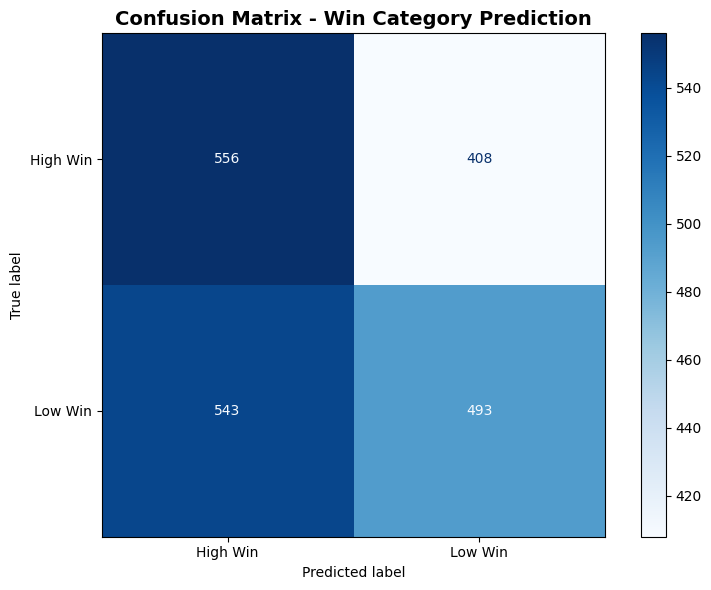


Classification Report:
              precision    recall  f1-score   support

    High Win       0.51      0.58      0.54       964
     Low Win       0.55      0.48      0.51      1036

    accuracy                           0.52      2000
   macro avg       0.53      0.53      0.52      2000
weighted avg       0.53      0.52      0.52      2000



In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['High', 'Low'])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High Win', 'Low Win'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Win Category Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['High Win', 'Low Win']))

### 9.2 Feature Importance
Which stats matter most for predicting winning seasons?

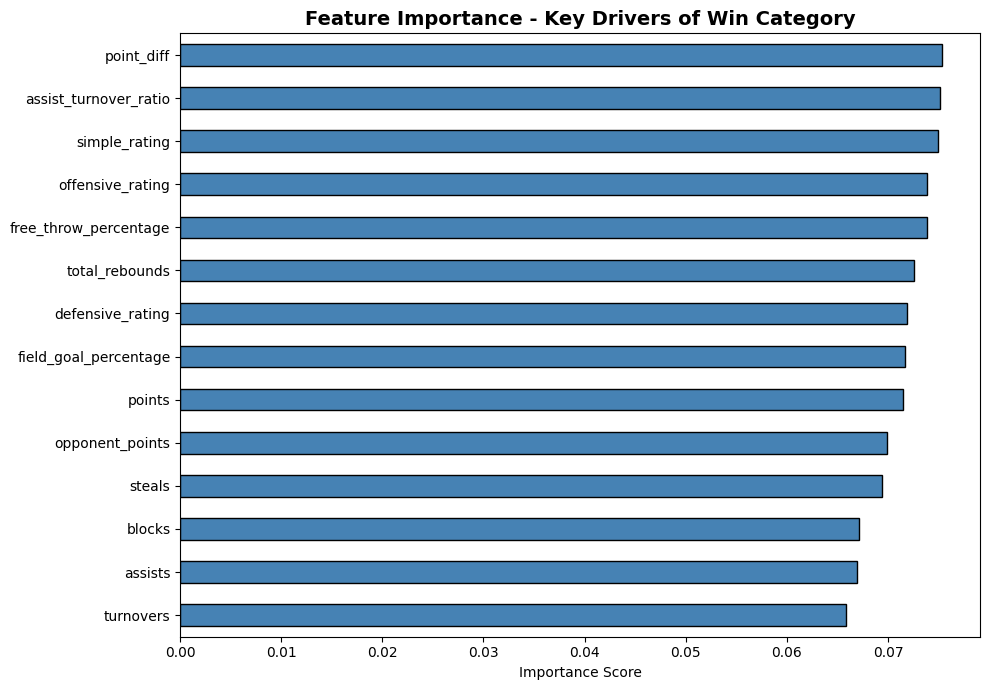


Top 5 Most Important Features:


point_diff               0.075335
assist_turnover_ratio    0.075146
simple_rating            0.074972
offensive_rating         0.073851
free_throw_percentage    0.073817
dtype: float64

In [33]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Key Drivers of Win Category', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
importances.sort_values(ascending=False).head()

---
## 10. Final Observations & Conclusions

### Key Findings:

1. **Field Goal Percentage is a key driver:** Teams with higher shooting accuracy have significantly higher win percentages (H1 confirmed).

2. **Net Rating strongly predicts success:** Teams with a positive net rating (scoring more than opponents) win significantly more games (H2 confirmed).

3. **Ball handling matters:** The assist-to-turnover ratio is a significant indicator of team success — efficient ball movement leads to more wins (H3 confirmed).

4. **Home court advantage exists:** Teams win at a significantly higher rate at home compared to away games (H4 confirmed).

5. **Scoring volume differentiates winners:** High-win teams score significantly more points per game than low-win teams (H5 confirmed).

6. **Top performance drivers (from model):** Simple rating, point differential, and offensive/defensive ratings are the most important features for predicting season success.

### Implications for Coaching & Recruitment:
- **Prioritize shooting efficiency** over volume — field goal percentage matters more than attempts.
- **Reduce turnovers** — the assist-to-turnover ratio is a key differentiator between winning and losing teams.
- **Focus on defense:** Defensive rating and limiting opponent scoring are as important as offensive output.
- **Leverage home court:** Schedule strategically, as home performance significantly exceeds away performance.
- **Recruit well-rounded players** who contribute to both ends of the floor (points + rebounds + assists).

In [34]:
print("="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Hypotheses Tested: 5")
print(f"Classification Model Accuracy: {accuracy*100:.1f}%")
print(f"Top Performance Driver: {importances.sort_values(ascending=False).index[0]}")
print("="*60)

ANALYSIS COMPLETE
Dataset: 10000 rows × 43 columns
Hypotheses Tested: 5
Classification Model Accuracy: 52.4%
Top Performance Driver: point_diff
